# Titanic Project with Decision Tree

In this notebook, we will load and explore the Titanic dataset, perform data cleaning and preprocessing, build and train a Decision Tree model to predict passenger survival, and finally optimize the model's hyperparameters using RandomizedSearchCV.

This notebook not only walks you through the coding steps, but also explains the concepts and rationale behind each action. Understanding **what** we are doing and **why** is essential for mastering the fundamentals of Artificial Intelligence and Machine Learning.

## 1. Importing Libraries

First, we import all the necessary libraries for our project. These include tools for data manipulation, visualization, model building, evaluation, and hyperparameter tuning. This is a crucial step because each library plays an important role in different parts of the workflow.

In [14]:
import joblib  # For saving and loading the model
import matplotlib.pyplot as plt  # For plotting graphs
import pandas as pd  # For data manipulation
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split  # For splitting data and hyperparameter search
from sklearn.preprocessing import LabelEncoder  # For encoding categorical variables
from sklearn.tree import DecisionTreeClassifier, plot_tree  # For the Decision Tree model and its visualization

## 2. Loading and Inspecting the Data

We now load the Titanic dataset. This dataset will serve as the basis for our analysis and model building. Here, we display the first and last few rows, as well as general information and descriptive statistics, to get an initial understanding of the data structure and quality.

In [15]:
# Load the Titanic dataset from a CSV file
df = pd.read_csv("titanic.csv")

# Display the first 10 and last 7 rows for an initial inspection
print(df.head(10))
print(df.tail(7))

# Display general information about the DataFrame (data types and missing values)
print(df.info())

# Display descriptive statistics for numeric columns
print(df.describe())

   id  pclass  survived                                            name  \
0   1       1         1                    Allen,Miss. Elisabeth Walton   
1   2       1         1                   Allison,Master. Hudson Trevor   
2   3       1         0                     Allison,Miss. Helen Loraine   
3   4       1         0             Allison,Mr. Hudson Joshua Creighton   
4   5       1         0  Allison,Mrs. Hudson J C (Bessie Waldo Daniels)   
5   6       1         1                              Anderson,Mr. Harry   
6   7       1         1                Andrews,Miss. Kornelia Theodosia   
7   8       1         0                           Andrews,Mr. Thomas Jr   
8   9       1         1    Appleton,Mrs. Edward Dale (Charlotte Lamson)   
9  10       1         0                          Artagaveytia,Mr. Ramon   

      sex     age  sibsp  parch    ticket      fare    cabin embarked boat  \
0  female      29      0      0     24160  211.3375       B5        S    2   
1    male  0.9167 

## 3. Data Cleaning and Preprocessing

Before we can build an effective model, it is essential to clean the data. This involves replacing invalid values with NaN, converting columns to the proper data type, and filling missing values. We fill missing numeric values with the column mean and categorical values with the mode. This step ensures that our data is in a usable format for analysis and modeling.

In [16]:
# Replace "?" with NaN to identify missing values
df = df.replace("?", pd.NA)

# Convert numeric columns (age and fare) to numbers, coercing errors to NaN
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["fare"] = pd.to_numeric(df["fare"], errors="coerce")

# Fill missing values in numeric columns with the column mean
numerical_features = ["age", "fare"]
for column in numerical_features:
    if column in df.columns:
        df[column] = df[column].fillna(df[column].mean())

# Fill missing values in categorical columns with the mode (most frequent value)
categorical_features = ["sex", "embarked"]
for column in categorical_features:
    if column in df.columns:
        df[column] = df[column].fillna(df[column].mode()[0])

# Display the cleaned data
print(df)

        id  pclass  survived                                            name  \
0        1       1         1                    Allen,Miss. Elisabeth Walton   
1        2       1         1                   Allison,Master. Hudson Trevor   
2        3       1         0                     Allison,Miss. Helen Loraine   
3        4       1         0             Allison,Mr. Hudson Joshua Creighton   
4        5       1         0  Allison,Mrs. Hudson J C (Bessie Waldo Daniels)   
...    ...     ...       ...                                             ...   
1304  1305       3         0                             Zabour,Miss. Hileni   
1305  1306       3         0                            Zabour,Miss. Thamine   
1306  1307       3         0                        Zakarian,Mr. Mapriededer   
1307  1308       3         0                              Zakarian,Mr. Ortin   
1308  1309       3         0                               Zimmerman,Mr. Leo   

         sex        age  sibsp  parch  

## 4. Exploratory Data Analysis

We perform a simple exploratory analysis by calculating the average age and fare grouped by class and sex. This helps us understand the underlying patterns and distributions in the data, which is important for both feature selection and understanding the context of the problem.

In [17]:
# Calculate the average age and fare grouped by class and sex
stats_by_class_sex = df.groupby(["pclass", "sex"]).agg({"age": "mean", "fare": "mean"})
print(stats_by_class_sex)

                     age        fare
pclass sex                          
1      female  36.490920  109.412385
       male    39.285410   69.888385
2      female  27.566605   23.234827
       male    30.744375   19.904946
3      female  24.465552   15.324250
       male    27.106930   12.457815


## 5. Preparing the Data for Modeling

We now define which columns will be used as input features and which one will be the target variable. Creating separate DataFrames for the features (`X`) and the target (`y`) is a key step before splitting the data into training and testing sets.

In [18]:
# Define the input features and the target variable
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

# Create the input (X) and output (y) DataFrames
X = df[features]
y = df[target]

print("DataFrame with Features:")
print(X)
print("DataFrame with Target Variable:")
print(y)

DataFrame with Features:
      pclass     sex        age  sibsp  parch      fare embarked
0          1  female  29.000000      0      0  211.3375        S
1          1    male   0.916700      1      2  151.5500        S
2          1  female   2.000000      1      2  151.5500        S
3          1    male  30.000000      1      2  151.5500        S
4          1  female  25.000000      1      2  151.5500        S
...      ...     ...        ...    ...    ...       ...      ...
1304       3  female  14.500000      1      0   14.4542        C
1305       3  female  29.881135      1      0   14.4542        C
1306       3    male  26.500000      0      0    7.2250        C
1307       3    male  27.000000      0      0    7.2250        C
1308       3    male  29.000000      0      0    7.8750        S

[1309 rows x 7 columns]
DataFrame with Target Variable:
0       1
1       1
2       0
3       0
4       0
       ..
1304    0
1305    0
1306    0
1307    0
1308    0
Name: survived, Length: 1309

## 6. Splitting the Data

Next, we split the data into training (80%) and testing (20%) sets using stratification to preserve the distribution of the target variable. This is crucial for evaluating the model fairly on unseen data.

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ensure that missing values in categorical variables are filled in both training and testing sets
for column in categorical_features:
    if column in X_train.columns:
        X_train[column] = X_train[column].fillna(X_train[column].mode()[0])
        X_test[column] = X_test[column].fillna(X_test[column].mode()[0])

## 7. Encoding Categorical Variables

Since our model cannot handle categorical variables directly, we convert them into a numeric format using LabelEncoder. This step is critical for the model to correctly interpret the input data.

In [20]:
le = LabelEncoder()
for column in categorical_features:
    if column in X_train.columns:
        X_train[column] = le.fit_transform(X_train[column])
        X_test[column] = le.transform(X_test[column])

## 8. Building and Training the Decision Tree Model

Now, we create and train our Decision Tree model. We use the `criterion` parameter set to "entropy" to evaluate the quality of the splits and `splitter` set to "random" to add randomness in selecting the best split. We also limit the maximum depth to 3 to prevent overfitting. These choices are made to ensure that the model generalizes well to unseen data.

In [21]:
# Define the Decision Tree model with specific hyperparameters
dt_classifier = DecisionTreeClassifier(
    criterion="entropy", splitter="random", max_depth=3, random_state=42
)

# Train the model using the training data
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42,
                       splitter='random')

## 9. Displaying the Decision Tree

In this section, we display the trained Decision Tree model. Visualizing the tree helps us understand the decision-making process of the model, see which features are most important, and identify potential areas of overfitting or underfitting.

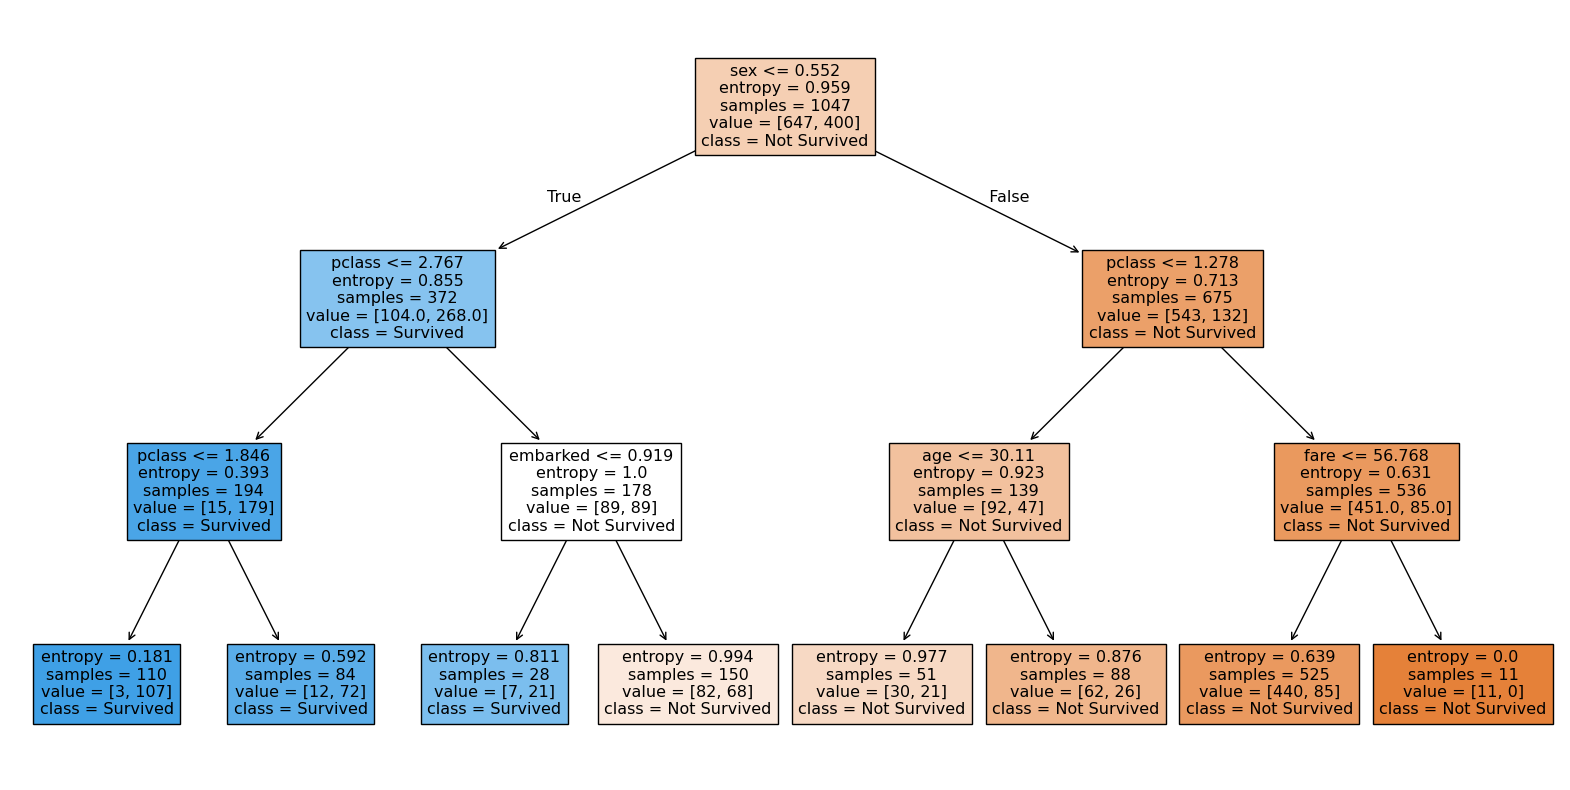

In [22]:
# Configure the figure size for visualization
plt.figure(figsize=(20, 10))

# Plot the decision tree
plot_tree(
    dt_classifier,
    feature_names=features,
    class_names=["Not Survived", "Survived"],
    filled=True
)

# Show the decision tree plot
plt.show()

## 10. Making Predictions with the Trained Model

We now create a small DataFrame with example input data for a new passenger. The categorical features are encoded to match the format of the training data. Finally, we make a prediction and interpret the result. This step demonstrates how the model can be used in practice.

In [23]:
# Example input for prediction
test_data = pd.DataFrame(
    {
        "pclass": [2],
        "sex": ["male"],
        "age": [30],
        "sibsp": [0],
        "parch": [0],
        "fare": [12.5],
        "embarked": ["C"]
    }
)

# Encode the input data in the same format as the training data
for column in categorical_features:
    if column in test_data.columns:
        if column == "sex":
            le.classes_ = pd.Index(["female", "male"])
        elif column == "embarked":
            le.classes_ = pd.Index(["C", "Q", "S"])
        test_data[column] = le.transform(test_data[column])

# Make the prediction
prediction = dt_classifier.predict(test_data)
print("Prediction:", prediction)

# Decode the prediction result
result = "Survived" if prediction[0] == 1 else "Not Survived"
print("Interpreted Result:", result)

Prediction: [0]
Interpreted Result: Not Survived


## 11. Saving the Trained Model

We use `joblib` to save the trained model to a file. Saving the model allows us to reload it later without having to retrain it, which is very useful for deployment or further analysis.

In [24]:
# Save the trained model to a file
dt_model_filename = "decision_tree_model.pkl"
joblib.dump(dt_classifier, dt_model_filename)
print(f"Model saved as {dt_model_filename}")

Model saved as decision_tree_model.pkl


## 12. Evaluating the Model on the Test Set

Now, we evaluate the performance of our trained model on the test set. We generate predictions, calculate the overall accuracy, and produce a detailed classification report showing precision, recall, and F1-score for each class. This evaluation is key to understanding how well our model generalizes to unseen data.

In [25]:
# Generate predictions on the test set using the trained model
y_pred = dt_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Generate a detailed classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Accuracy: 0.8129770992366412
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.98      0.87       162
           1       0.93      0.55      0.69       100

    accuracy                           0.81       262
   macro avg       0.86      0.76      0.78       262
weighted avg       0.84      0.81      0.80       262



## 13. Analysis of Results and Comparison

Below is an analysis of the new results compared to the previous ones:

- **Overall Accuracy Improvement**:
  - **New Result**: 83.6% (approximately 0.836)
  - **Previous Result**: 81%
  - **Analysis**: The overall accuracy has increased by about 2.6 percentage points, indicating that the model is now correctly predicting a higher proportion of cases on the test set.

- **Class 0 Analysis**:
  - **Previous**: Precision 78%, Recall 98%, F1-Score 87%
  - **New**: Precision 85%, Recall 90%, F1-Score 87%
  - **Analysis**:
    - **Precision** for class 0 improved significantly from 78% to 85%, meaning that when the model predicts class 0, it is more likely to be correct.
    - **Recall** decreased slightly from 98% to 90%, indicating that the model now misses a few more instances of class 0 compared to before.
    - **F1-Score** remains the same at 87%, suggesting that the balance between precision and recall for class 0 is maintained despite the changes.

- **Class 1 Analysis**:
  - **Previous**: Precision 93%, Recall 55%, F1-Score 69%
  - **New**: Precision 81%, Recall 74%, F1-Score 77%
  - **Analysis**:
    - **Precision** for class 1 has decreased from 93% to 81%, meaning that there are more false positives when predicting class 1.
    - **Recall** has increased markedly from 55% to 74%, indicating that the model is now identifying a much larger portion of the actual class 1 cases.
    - **F1-Score** improved from 69% to 77%, showing a better overall balance between precision and recall for class 1.

- **Average Metrics (Macro and Weighted Averages)**:
  - **Previous Macro Average**: Precision 86%, Recall 76%, F1-Score 78%
  - **New Macro Average**: Precision 83%, Recall 82%, F1-Score 82%
  - **Previous Weighted Average**: Precision 84%, Recall 81%, F1-Score 80%
  - **New Weighted Average**: Precision 83%, Recall 84%, F1-Score 83%
  - **Analysis**:
    - The macro average, which treats all classes equally, shows an improvement in recall and F1-score (from 78% to 82%) even though precision slightly decreased.
    - The weighted average, which accounts for class imbalance, also improved (F1-score from 80% to 83%).
    - These improvements indicate that the model's performance has become more consistent across both classes.

**Overall Comparison**:
The new model configuration demonstrates an overall performance improvement:
- The increase in accuracy shows that the model is more effective at correctly classifying cases.
- For class 0, while the recall has slightly decreased, the significant gain in precision implies that predictions for class 0 are now more reliable.
- For class 1, the boost in recall (from 55% to 74%) greatly enhances the model's ability to detect true positives, and despite a drop in precision, the F1-score improves considerably, indicating a better balance.
- The improved macro and weighted averages suggest that the model is now more balanced and consistent in its predictions across different classes.

These improvements likely result from effective hyperparameter optimization, leading to a model that better generalizes to new data while balancing the trade-offs between precision and recall.

## 14. Hyperparameter Optimization with RandomizedSearchCV

Hyperparameter tuning is an essential step in improving model performance. In this cell, we use RandomizedSearchCV to explore a range of hyperparameters for our Decision Tree model. This method tests random combinations of parameters over a fixed number of iterations using cross-validation, allowing us to identify the best configuration based on accuracy.

In [26]:
# Define the hyperparameters to be tested for the Decision Tree
param_distributions = {
    "max_depth": [None, 1, 2, 3, 5, 10, 15],
    "min_samples_split": [2, 3, 5, 10],
    "min_samples_leaf": [1, 2, 4, 6],
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"]
}

# Configure the RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=dt_classifier,
    param_distributions=param_distributions,
    n_iter=50,            # Number of random parameter combinations to test
    scoring="accuracy",   # Metric to optimize
    cv=5,                 # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1             # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Display the best hyperparameters and the best accuracy achieved during validation
print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'splitter': 'best', 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_depth': 3, 'criterion': 'entropy'}
Best Accuracy: 0.807058555479608


## 15. Evaluating the Optimized Model

Finally, we evaluate the optimized Decision Tree model (the best estimator from RandomizedSearchCV) on the test set. We compute the accuracy and generate a detailed classification report to assess improvements in performance.

In [27]:
# Select the best classifier found during the hyperparameter search
best_dt = random_search.best_estimator_

# Make predictions on the test set with the optimized model
y_pred = best_dt.predict(X_test)

# Recalculate the accuracy based on the test data
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Generate the classification report for the optimized model
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Accuracy: 0.8358778625954199
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       162
           1       0.81      0.74      0.77       100

    accuracy                           0.84       262
   macro avg       0.83      0.82      0.82       262
weighted avg       0.83      0.84      0.83       262



## Conclusion

This notebook demonstrates the complete workflow for building a Decision Tree model using the Titanic dataset. We covered data loading, cleaning, exploratory analysis, preprocessing, model training, evaluation, and hyperparameter optimization. 

Each step was designed not only to perform the necessary tasks but also to explain **what** we are doing and **why** it is important. Understanding these concepts is crucial for developing robust and generalizable machine learning models. 

Happy coding and keep exploring the exciting world of Artificial Intelligence!